In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import pandas as pd
import casadi as ca
from scipy.optimize import fsolve

# ------------------------------
# Parâmetros
# ------------------------------
M = 0.028
Ta = 301
La = 1500
ro = 1000
Tw = 305
Lw = 1500
Lr = 500
Hw = 1500
Dw = 0.121
Dr = 0.121

u = 1
u1 = 50 ** (u - 1)

Dbh = 0.121
Da = 0.189
Hr = 500
Hbh = 500
Lbh = 500
Tr = 301
PI = 0.22e-5
Cpc = 2e-3
Civ = 10e-4
Cr = 2.6e-4
Crh = 10e-3

Pr = 15e6
Ps = 2e6
vo = 1 / ro
g = 9.81
Riser_p_fric = 0.5
R = 8.314
GOR = 0.1
dp_t_fric = 1.0e5
dp_bh_fric = 5.0e4
Ha = 1000

# Cálculo de áreas
Aw = (ca.pi * (Dw ** 2)) / 4
Aa = (ca.pi * (Da ** 2)) / 4 - (ca.pi * (Dw ** 2)) / 4
Ar = (ca.pi * (Dr ** 2)) / 4
Va = La * Aa
Abh = (ca.pi * (Dbh ** 2)) / 4

# ------------------------------
# Funções do modelo
# ------------------------------
def fun(t, x, par, z):
    x1, x2, x3 = x[0], x[1], x[2]
    par, u1, GOR = par[0], par[1], par[2]

    Pai = z[0]
    Pwh = z[1]
    Pwi = z[2]
    Pwb = z[3]
    wiv = z[4]
    wro = z[5]
    wpc = z[6]
    wpg = z[7]
    wpo = z[8]
    wrg = z[9]
    ro_w = z[10]
    ro_a = z[11]

    dx1 = par - wiv
    dx2 = wiv + wrg - wpg
    dx3 = wro - wpo

    return ca.vertcat(dx1, dx2, dx3)


def modelo(x, par, z):
    par, u1, GOR = par[0], par[1], par[2]
    Pai = z[0]
    Pwh = z[1]
    Pwi = z[2]
    Pwb = z[3]
    wiv = z[4]
    wro = z[5]
    wpc = z[6]
    wpg = z[7]
    wpo = z[8]
    wrg = z[9]
    ro_w = z[10]
    ro_a = z[11]

    return {
        'Pai': Pai,
        'Pwh': Pwh,
        'Pwi': Pwi,
        'Pwb': Pwb,
        'wiv': wiv,
        'wro': wro,
        'wpc': wpc,
        'wpg': wpg,
        'wpo': wpo,
        'wrg': wrg,
        'ro_w': ro_w,
        'ro_a': ro_a
    }


def equacoes_algebricas(x, par, z):
    Pai = z[0]
    Pwh = z[1]
    Pwi = z[2]
    Pwb = z[3]
    wiv = z[4]
    wro = z[5]
    wpc = z[6]
    wpg = z[7]
    wpo = z[8]
    wrg = z[9]
    ro_w = z[10]
    ro_a = z[11]

    x1, x2, x3 = x[0], x[1], x[2]
    par, u1, GOR = par[0], par[1], par[2]

    D = ca.sqrt(Aw * 4 / np.pi)
    y1 = ca.fmax(1e-9, Pai - Pwi)
    y2 = ca.fmax(1e-9, Pr - Pwb)
    y3 = ca.fmax(1e-9, Pwh - Ps)

    veloc = wpc / Aw

    F1 = Pai - ((R * Ta / (Va * M)) + ((g * La) / Va)) * x1
    F2 = Pwh - (R * Tw / M) * (x2 / (Lw * Aw - (vo * x3)))
    F3 = ro_w - ((x2 + x3) / (Lw * Aw))
    F4 = Pwi - (Pwh + ((x3 + x2) * g / Aw))
    F5 = Pwb - (Pwi + (ro * g * Hr))
    F6 = ro_a - ((M * Pai) / (R * Ta))
    F7 = wiv - Civ * ca.sqrt(ro_a * y1)
    F8 = wpc - Cpc * ca.sqrt(ro_w * y3) * 50 ** (u1 - 1)
    F9 = wpg - ((x2 / (x2 + x3 + 1e-9)) * wpc)
    F10 = wpo - ((x3 / (x2 + x3 + 1e-9)) * wpc)
    F11 = wro - Cr * ca.sqrt(ro * y2)
    F12 = wrg - (GOR * wro)

    return ca.vertcat(F1, F2, F3, F4, F5, F6, F7, F8, F9, F10, F11, F12)


# ------------------------------
# Integrador DAE
# ------------------------------
def fun_integrador(dt):
    x_sym = ca.SX.sym('x', 3)
    z_sym = ca.SX.sym('z', 12)
    par_sym = ca.SX.sym('par', 3)

    dx_sym = fun(0, x_sym, par_sym, z_sym)
    F_alg = equacoes_algebricas(x_sym, par_sym, z_sym)

    dae = {'x': x_sym, 'z': z_sym, 'p': par_sym, 'ode': dx_sym, 'alg': F_alg}
    opts = {
        'tf': dt,
        'abstol': 1e-4,
        'reltol': 1e-4,
        'max_num_steps': 20000,
        'disable_internal_warnings': False,
    }
    integrador = ca.integrator('integrador', 'idas', dae, opts)
    return integrador, modelo


# ------------------------------
# Simulação CasADi
# ------------------------------
def simular_2(integrador, modelo, params, y0, z0_vals, t):
    x_current = np.array(y0)
    z_current = np.array(z0_vals)

    results = {key: [] for key in
               ['Pai', 'Pwh', 'Pwi', 'Pwb', 'wiv', 'wro', 'wpc', 'wpg', 'wpo', 'wrg',
                'ro_w', 'ro_a', 'x1', 'x2', 'x3']}

    for ti in t:
        res = integrador(x0=x_current, z0=z_current, p=params)

        x_next = res['xf'].full().flatten()
        z_next = res['zf'].full().flatten()

        model_output = modelo(x_next, params, z_next)

        results['x1'].append(float(x_next[0]))
        results['x2'].append(float(x_next[1]))
        results['x3'].append(float(x_next[2]))

        for key in results:
            if key not in ['x1', 'x2', 'x3']:
                results[key].append(float(model_output[key]))

        x_current = x_next
        z_current = z_next

    for key in results:
        results[key] = np.array(results[key])

    return results


# ------------------------------
# Função explícita p/ NMPC
# ------------------------------
def fun_casadi(x_sym, p_sym):
    epsilon = 1e-9

    x1, x2, x3 = x_sym[0], x_sym[1], x_sym[2]
    par, u1, GOR = p_sym[0], p_sym[1], p_sym[2]

    Pai = ((R * Ta / (Va * M)) + ((g * La) / Va)) * x1

    gas_volume = ca.fmax(epsilon, (Lw * Aw - (vo * x3)))
    Pwh = (R * Tw / M) * (x2 / gas_volume)

    ro_w = (x2 + x3) / (Lw * Aw + epsilon)
    y3 = ca.fmax(0.0, (Pwh - Ps))

    wpc_arg = ca.fmax(epsilon, ro_w * y3)
    wpc = Cpc * ca.sqrt(wpc_arg) * 50 ** (u1 - 1)

    Pwi = Pwh + ((x3 + x2) * g) / Aw
    Pwb = Pwi + (ro * g * Hr)

    ro_a = (M * Pai) / (R * Ta + epsilon)
    y1 = ca.fmax(epsilon, (Pai - Pwi))
    y2 = ca.fmax(epsilon, (Pr - Pwb))

    wiv = Civ * ca.sqrt(ca.fmax(epsilon, ro_a * y1))
    wro = Cr * ca.sqrt(ca.fmax(epsilon, ro * y2))
    wrg = GOR * wro

    wpg = (x2 / (x2 + x3 + epsilon)) * wpc
    wpo = (x3 / (x2 + x3 + epsilon)) * wpc

    dx1 = par - wiv
    dx2 = wiv + wrg - wpg
    dx3 = wro - wpo

    dx_sym = ca.vertcat(dx1, dx2, dx3)

    model_outputs = {
        'Pai': Pai, 'Pwh': Pwh, 'Pwi': Pwi, 'Pwb': Pwb,
        'wiv': wiv, 'wro': wro, 'wpc': wpc, 'wpg': wpg,
        'wpo': wpo, 'wrg': wrg, 'ro_w': ro_w, 'ro_a': ro_a
    }

    return dx_sym, model_outputs


# ------------------------------
# Execução da simulação
# ------------------------------
X_eq_vals = np.array([
    1713.946,
    424.3868,
    4454.146
])

U_eq_vals = np.array([
    1.2,
    0.8,
    0.01
])

t0, tf, dt = 0, 18000, 1
t = np.arange(t0, tf, dt)

y0 = X_eq_vals
z0_vals = np.array([
    7183839.554, 2991744.663, 7138588.549, 12043588.55,
    1.90714269, 14.13695208, 33.43556308, 2.911066071,
    30.52449701, 0.141369521, 281.8106616, 80.37817471
])

w_inj = 1.24
u1 = 0.8
GOR = 0.01

params = np.array([w_inj, u1, GOR])

integrador, modelo = fun_integrador(dt=1)
results_casadi = simular_2(integrador, modelo, params, y0, z0_vals, t)

print("Simulação CasADi concluída.")

y_casadi_pwh_pa = results_casadi['Pwb']


Simulação CasADi concluída.


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      153
Number of nonzeros in inequality constraint Jacobian.:       10
Number of nonzeros in Lagrangian Hessian.............:      100

Total number of variables............................:       43
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       33
Total number of inequality constraints...............:       10
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:       10
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.0908225e+14 4.45e+03 8.71e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

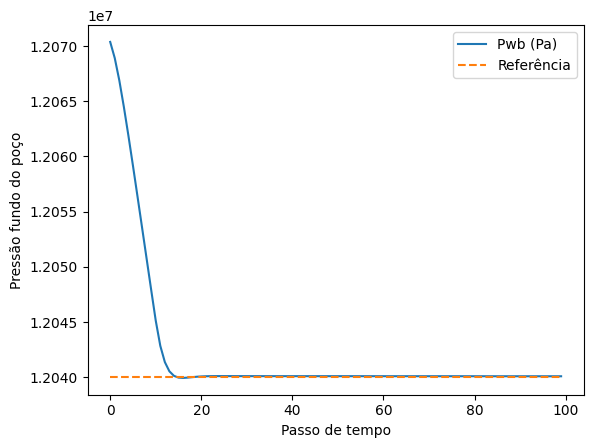

In [ ]:
import casadi as ca
import numpy as np

#Modelo explícito simplificado
x = ca.SX.sym("x", 3)   # estados
u = ca.SX.sym("u")      # w_inj manipulada
u1 = 0.8                # fixo
GOR = 0.01              # fixo

dx, out = fun_casadi(x, ca.vertcat(u, u1, GOR))
Pwb = out["Pwb"]

f = ca.Function("f", [x, u], [dx])
g = ca.Function("g", [x, u], [Pwb])

#Integrador RK4
def rk4_step(xk, uk, dt):
    k1 = f(xk, uk)
    k2 = f(xk + dt/2 * k1, uk)
    k3 = f(xk + dt/2 * k2, uk)
    k4 = f(xk + dt * k3, uk)
    return xk + dt/6*(k1 + 2*k2 + 2*k3 + k4)

#NMPC 
N = 10          
dt = 1

opti = ca.Opti()
X = opti.variable(3, N+1)
U = opti.variable(1, N)
X0 = opti.parameter(3)
Pref = opti.parameter(1)



# custo: erro quadrático + penalidade na entrada
J = 0
for k in range(N):
    J += (g(X[:,k], U[:,k]) - Pref)**2
    J += 1e7*U[:,k]**2 # a pq tem 1e7 pq e grande pra krl o outro
opti.minimize(J)

# dinâmica
opti.subject_to(X[:,0]==X0)
for k in range(N):
    X_next = rk4_step(X[:,k], U[:,k], dt)
    opti.subject_to(X[:,k+1]==X_next)

# limites de operação
opti.subject_to(opti.bounded(0.1, U, 10.0))

opti.solver("ipopt")

#Loop de simulação
Tsim = (100)
x_real = X_eq_vals.copy()
z_real = z0_vals.copy()
hist_Pwb = []
hist_u = []

for t_i in range(Tsim):
    opti.set_value(X0, x_real)
    opti.set_value(Pref, [12.04e6])   # referência

    try:
        sol = opti.solve()
    except:
        sol = opti.debug

    u_MPC = sol.value(U[:,0])
    hist_u.append(u_MPC)

    # Aplica no modelo real
    params = [u_MPC, u1, GOR]
    res = integrador(x0=x_real, z0=z_real, p=params)
    x_real = res["xf"].full().flatten()
    z_real = res["zf"].full().flatten()

    out = modelo(x_real, params, z_real)
    hist_Pwb.append(float(out["Pwb"]))

    opti.set_initial(sol.value_variables()) 

#Resultado ---
import matplotlib.pyplot as plt
plt.plot(hist_Pwb, label="Pwb (Pa)")
plt.plot([12.04e6]*Tsim, "--", label="Referência")
plt.xlabel("Passo de tempo")
plt.ylabel("Pressão fundo do poço")
plt.legend()
plt.show()


Text(0.5, 0, 'Passo de tempo')

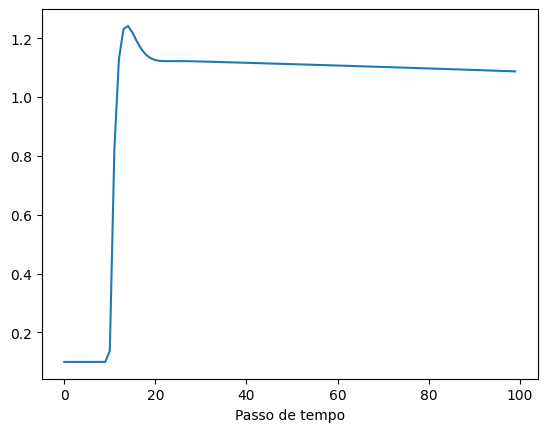

In [6]:
plt.plot(hist_u, label="w_inj (m³/s)")
plt.xlabel("Passo de tempo")